# Étude du papier: Decentralized Proximal Gradient Algorithms With Linear Convergence Rates

Notebook de vérification/correction du travail initial, avec ajout des méthodes manquantes de l'article:
- DGD (baseline du cours)
- Gradient Tracking (baseline du cours)
- PUDA et ses instances de l'appendice A: Prox-ED, Prox-ATC I, Prox-ATC II

On traite deux cas:
1. cas lisse (`\lambda=0`) pour comparer directement aux méthodes de cours;
2. cas non lisse (`\lambda>0`) pour valider l'apport proximal du papier.


In [56]:
from pathlib import Path
import pickle
import warnings

import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().resolve()
if not (repo_root / 'data').exists():
    if (repo_root.parent / 'data').exists():
        repo_root = repo_root.parent
    else:
        raise FileNotFoundError('Unable to locate the repository data folder from this notebook.')


def as_1d(array_like):
    return np.asarray(array_like, dtype=float).reshape(-1)


def load_first_database():
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=DeprecationWarning)
        with open(repo_root / 'data' / 'first_database.pkl', 'rb') as f:
            x_full, y_full = pickle.load(f)
    return as_1d(x_full), as_1d(y_full)


def split_indices_equally(n_samples, n_agents):
    return [np.asarray(idx, dtype=int) for idx in np.array_split(np.arange(n_samples), n_agents)]


def rbf_kernel(x_data, x_landmarks):
    x = as_1d(x_data).reshape(-1, 1)
    z = as_1d(x_landmarks).reshape(1, -1)
    return np.exp(-((x - z) ** 2))


def cov_matrix(x_landmarks):
    return rbf_kernel(x_landmarks, x_landmarks)


def cross_cov_matrix(x_data, x_landmarks):
    return rbf_kernel(x_data, x_landmarks)


def build_nystrom_problem(x, y, n=100, m=10, selection=True, seed=0, landmarks=None):
    x = as_1d(x)
    y = as_1d(y)
    x_n = x[:n]
    y_n = y[:n]

    if landmarks is not None:
        x_m = as_1d(landmarks)
        landmark_indices = np.array([], dtype=int)
    else:
        rng = np.random.default_rng(seed)
        if selection:
            landmark_indices = np.sort(rng.choice(np.arange(n), size=m, replace=False))
            x_m = x_n[landmark_indices]
        else:
            landmark_indices = np.array([], dtype=int)
            x_m = np.linspace(-1.0, 1.0, m)

    M = cross_cov_matrix(x_n, x_m)
    Kmm = cov_matrix(x_m)
    return {
        'x_n': x_n,
        'y_n': y_n,
        'x_m': x_m,
        'M': M,
        'Kmm': Kmm,
        'landmark_indices': landmark_indices,
    }


def solve_centralized(M, y, Kmm, sigma=0.5, nu=1.0):
    M = np.asarray(M, dtype=float)
    y = as_1d(y)
    Kmm = np.asarray(Kmm, dtype=float)
    m_loc = Kmm.shape[0]
    H = M.T @ M + (sigma ** 2) * Kmm + nu * np.eye(m_loc)
    b = M.T @ y
    return np.linalg.solve(H, b)


def quadratic_form_for_agent(M_i, y_i, Kmm, n_agents, sigma=0.5, nu=1.0):
    m_loc = Kmm.shape[0]
    Q_i = M_i.T @ M_i + (sigma ** 2 / n_agents) * Kmm + (nu / n_agents) * np.eye(m_loc)
    q_i = M_i.T @ as_1d(y_i)
    return Q_i, q_i


def make_agent_data(problem, n_agents, sigma=0.5, nu=1.0):
    M = np.asarray(problem['M'], dtype=float)
    y = as_1d(problem['y_n'])
    Kmm = np.asarray(problem['Kmm'], dtype=float)
    splits = split_indices_equally(len(y), n_agents)

    agents = []
    for agent_id, idx in enumerate(splits):
        M_i = M[idx]
        y_i = y[idx]
        Q_i, q_i = quadratic_form_for_agent(M_i, y_i, Kmm, n_agents, sigma=sigma, nu=nu)
        Q_i = 0.5 * (Q_i + Q_i.T)
        agents.append({
            'id': agent_id,
            'indices': idx,
            'M': M_i,
            'y': y_i,
            'Q': Q_i,
            'q': q_i,
        })
    return agents


def local_gradient(alpha, agent):
    alpha = as_1d(alpha)
    return agent['Q'] @ alpha - agent['q']


def cycle_graph_weights(n_agents):
    A = np.zeros((n_agents, n_agents), dtype=float)
    for i in range(n_agents):
        A[i, i] = 0.5
        A[i, (i - 1) % n_agents] = 0.25
        A[i, (i + 1) % n_agents] = 0.25
    return A


np.random.seed(7)
plt.rcParams['figure.figsize'] = (12, 4.5)


## Données et constantes

On reprend le cadre noyau Nyström du projet (`first_database.pkl`) avec un graphe cycle à 5 agents.


In [57]:
# Paramètres du problème noyau
sigma = 0.5
nu = 1.0

n = 100          # nombre d'échantillons utilisés
m = 20           # dimension de alpha (landmarks Nyström)
n_agents = 5

# Paramètres expériences
#n_iter = 3500
n_iter = 50000
l1_reg = 1e-3

x_full, y_full = load_first_database()

problem = build_nystrom_problem(x_full, y_full, n=n, m=m, selection=True, seed=7)
agents = make_agent_data(problem, n_agents, sigma=sigma, nu=nu)

A = cycle_graph_weights(n_agents)
I = np.eye(n_agents)

# Constantes locales de lissité/forte convexité (Assumption 1)
local_eigs = [np.linalg.eigvalsh(agent['Q']) for agent in agents]
delta = max(e.max() for e in local_eigs)
nu_local = min(e.min() for e in local_eigs)

# Bornes de pas du Théorème 1
# - Pour C = 0: mu < 2/delta
# - Pour C = I - A: mu < (2 - sigma_max(I-A))/delta
bound_c0 = 2.0 / delta
bound_cIA = (2.0 - np.linalg.eigvalsh(I - A).max()) / delta

print(f'delta (max local smoothness) = {delta:.6f}')
print(f'nu local min = {nu_local:.6f}')
print(f'mu bound, C=0          : mu < {bound_c0:.6f}')
print(f'mu bound, C=I-A (ATCII): mu < {bound_cIA:.6f}')


delta (max local smoothness) = 232.333023
nu local min = 0.200000
mu bound, C=0          : mu < 0.008608
mu bound, C=I-A (ATCII): mu < 0.004715


## Implémentations

- `run_dgd`: baseline DGD
- `run_gt`: baseline Gradient Tracking
- `run_puda`: PUDA générique (équations (17a)-(17c) du papier)
- `solve_centralized_l1`: solveur centralisé FISTA pour la référence non lisse


In [58]:
def prox_l1(x, tau):
    return np.sign(x) * np.maximum(np.abs(x) - tau, 0.0)


def solve_centralized_l1(M, y, Kmm, sigma, nu, l1, max_iter=60000, tol=1e-12):
    """Résolution centralisée de min f(alpha)+l1*||alpha||_1 via FISTA."""
    M = np.asarray(M, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)
    Kmm = np.asarray(Kmm, dtype=float)

    m_loc = Kmm.shape[0]
    H = M.T @ M + (sigma ** 2) * Kmm + nu * np.eye(m_loc)
    b = M.T @ y
    L = np.linalg.eigvalsh(H).max()

    x = np.zeros(m_loc)
    z = x.copy()
    t = 1.0

    for it in range(max_iter):
        grad = H @ z - b
        x_new = prox_l1(z - grad / L, l1 / L)

        if np.linalg.norm(x_new - x) <= tol * max(1.0, np.linalg.norm(x)):
            return x_new, it + 1

        t_new = 0.5 * (1.0 + np.sqrt(1.0 + 4.0 * t * t))
        z = x_new + ((t - 1.0) / t_new) * (x_new - x)
        x, t = x_new, t_new

    return x, max_iter


def run_dgd(agents, A, step, n_iter, alpha_star):
    n_agents_loc = len(agents)
    m_loc = alpha_star.size

    W = np.zeros((n_agents_loc, m_loc))
    errors = []

    for _ in range(n_iter):
        G = np.vstack([local_gradient(W[i], agents[i]) for i in range(n_agents_loc)])
        W = A @ W - step * G
        errors.append(np.linalg.norm(W.mean(axis=0) - alpha_star))

    return np.array(errors), W


def run_gt(agents, A, step, n_iter, alpha_star):
    n_agents_loc = len(agents)
    m_loc = alpha_star.size

    W = np.zeros((n_agents_loc, m_loc))
    Y = np.vstack([local_gradient(W[i], agents[i]) for i in range(n_agents_loc)])
    errors = []

    for _ in range(n_iter):
        W_next = A @ W - step * Y

        G_old = np.vstack([local_gradient(W[i], agents[i]) for i in range(n_agents_loc)])
        G_new = np.vstack([local_gradient(W_next[i], agents[i]) for i in range(n_agents_loc)])
        Y = A @ Y + (G_new - G_old)

        W = W_next
        errors.append(np.linalg.norm(W.mean(axis=0) - alpha_star))

    return np.array(errors), W


def run_puda(agents, A_bar, B, C, step, l1, n_iter, alpha_star):
    """
    PUDA générique du papier:
      Z_i = (I-C)W_{i-1} - mu * grad J(W_{i-1}) - B Y_{i-1}
      Y_i = Y_{i-1} + B Z_i
      W_i = prox_{mu R}(A_bar Z_i)
    avec R(w)=l1*||w||_1 (commun à tous les agents).
    """
    n_agents_loc = len(agents)
    m_loc = alpha_star.size

    I_loc = np.eye(n_agents_loc)
    W = np.zeros((n_agents_loc, m_loc))
    Y = np.zeros((n_agents_loc, m_loc))
    errors = []

    for _ in range(n_iter):
        G = np.vstack([local_gradient(W[i], agents[i]) for i in range(n_agents_loc)])
        Z = (I_loc - C) @ W - step * G - B @ Y
        Y = Y + B @ Z
        W = prox_l1(A_bar @ Z, step * l1)
        errors.append(np.linalg.norm(W.mean(axis=0) - alpha_star))

    return np.array(errors), W


## Expérience 1: cas lisse (`\lambda=0`)

Correction importante par rapport au notebook initial:
- PUDA est comparé à la bonne référence centralisée du même problème (pas de mélange lisse/non-lisse).


In [59]:
alpha_star_smooth = solve_centralized(
    problem['M'], problem['y_n'], problem['Kmm'], sigma=sigma, nu=nu
)

# Pas choisis (stables numériquement dans ce setup)
step_dgd = 0.0015
step_gt = 0.0027
step_puda = 0.0040

if not (step_puda < bound_cIA):
    raise ValueError('step_puda viole la borne du Théorème 1 pour C=I-A.')

smooth_hist = {}
smooth_hist['DGD'], _ = run_dgd(agents, A, step_dgd, n_iter, alpha_star_smooth)
smooth_hist['GT'], _ = run_gt(agents, A, step_gt, n_iter, alpha_star_smooth)

puda_settings = {
    'Prox-ED': ((I + A) / 2.0, 0.5 * (I - A), np.zeros_like(A)),
    'Prox-ATC I': (A @ A, I - A, np.zeros_like(A)),
    'Prox-ATC II': (A, I - A, I - A),
}

for name, (A_bar, B, C) in puda_settings.items():
    smooth_hist[name], _ = run_puda(
        agents,
        A_bar=A_bar,
        B=B,
        C=C,
        step=step_puda,
        l1=0.0,
        n_iter=n_iter,
        alpha_star=alpha_star_smooth,
    )

smooth_final = {name: float(hist[-1]) for name, hist in smooth_hist.items()}
smooth_final


{'DGD': 0.09214045626018048,
 'GT': 1.4824552414444358e-13,
 'Prox-ED': 1.1533260367132736e-13,
 'Prox-ATC I': 1.2261372360003084e-13,
 'Prox-ATC II': 1.317386708684514e-13}

## Expérience 2: cas non lisse (`\lambda>0`)

On ajoute la partie manquante du papier: optimisation composite avec proximal L1 commun.
Référence centralisée calculée par FISTA.


In [60]:
alpha_star_l1, fista_iters = solve_centralized_l1(
    problem['M'],
    problem['y_n'],
    problem['Kmm'],
    sigma=sigma,
    nu=nu,
    l1=l1_reg,
)

nonsmooth_hist = {}
for name, (A_bar, B, C) in puda_settings.items():
    nonsmooth_hist[name], _ = run_puda(
        agents,
        A_bar=A_bar,
        B=B,
        C=C,
        step=step_puda,
        l1=l1_reg,
        n_iter=n_iter,
        alpha_star=alpha_star_l1,
    )

nonsmooth_final = {name: float(hist[-1]) for name, hist in nonsmooth_hist.items()}
print(f'FISTA centralisé itérations = {fista_iters}')
nonsmooth_final


FISTA centralisé itérations = 17421


{'Prox-ED': 0.00968211410841658,
 'Prox-ATC I': 0.00968211410840994,
 'Prox-ATC II': 0.009682114108413981}

## Visualisation


Figure sauvegardée: /Users/p.gatt/Documents/GitHub/Coop_optim/litterature/puda_comparison.pdf


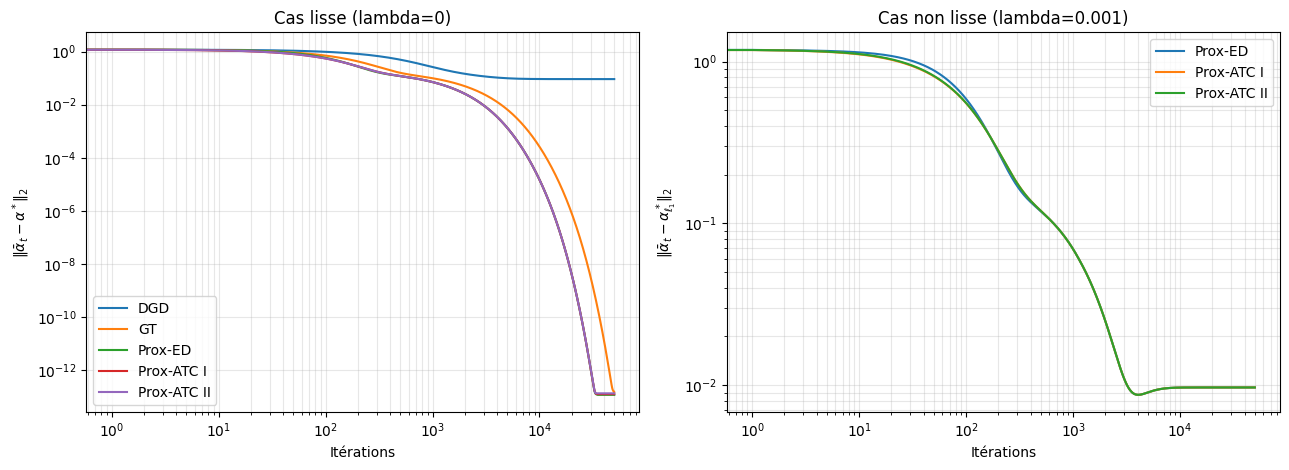

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for name in ['DGD', 'GT', 'Prox-ED', 'Prox-ATC I', 'Prox-ATC II']:
    axes[0].loglog(smooth_hist[name], label=name)
axes[0].set_title('Cas lisse (lambda=0)')
axes[0].set_xlabel('Itérations')
axes[0].set_ylabel(r'$\|\bar{\alpha}_t - \alpha^*\|_2$')
axes[0].grid(True, which='both', alpha=0.3)
axes[0].legend()

for name in ['Prox-ED', 'Prox-ATC I', 'Prox-ATC II']:
    axes[1].loglog(nonsmooth_hist[name], label=name)
axes[1].set_title(f'Cas non lisse (lambda={l1_reg})')
axes[1].set_xlabel('Itérations')
axes[1].set_ylabel(r'$\|\bar{\alpha}_t - \alpha^*_{\ell_1}\|_2$')
axes[1].grid(True, which='both', alpha=0.3)
axes[1].legend()

plt.tight_layout()

fig_path = repo_root / 'litterature' / 'puda_comparison.pdf'
fig.savefig(fig_path, bbox_inches='tight')
print(f'Figure sauvegardée: {fig_path}')
plt.show()


## Synthèse numérique


In [62]:
summary = {
    'step_sizes': {
        'DGD': step_dgd,
        'GT': step_gt,
        'PUDA family': step_puda,
    },
    'theorem1_bounds': {
        'mu < 2/delta (C=0)': float(bound_c0),
        'mu < (2-sigma_max(I-A))/delta (C=I-A)': float(bound_cIA),
    },
    'final_error_smooth': smooth_final,
    'final_error_nonsmooth': nonsmooth_final,
    'centralized_l1_fista_iters': int(fista_iters),
}

summary


{'step_sizes': {'DGD': 0.0015, 'GT': 0.0027, 'PUDA family': 0.004},
 'theorem1_bounds': {'mu < 2/delta (C=0)': 0.008608332885577092,
  'mu < (2-sigma_max(I-A))/delta (C=I-A)': 0.004715177764765672},
 'final_error_smooth': {'DGD': 0.09214045626018048,
  'GT': 1.4824552414444358e-13,
  'Prox-ED': 1.1533260367132736e-13,
  'Prox-ATC I': 1.2261372360003084e-13,
  'Prox-ATC II': 1.317386708684514e-13},
 'final_error_nonsmooth': {'Prox-ED': 0.00968211410841658,
  'Prox-ATC I': 0.00968211410840994,
  'Prox-ATC II': 0.009682114108413981},
 'centralized_l1_fista_iters': 17421}